# VLM-Based Encoding Models for Visual ROIs

## Aim
Move beyond CNN-only encoders by evaluating whether foundation vision-language models (VLMs) and LLM-derived semantic representations better explain responses in Visual ROI-specific brain responses (vertices), while retaining performance in early retinotopic areas.

**ROI Sets Covered:**
- **Early retinotopic visual regions (prf-visualrois):** V1v, V1d, V2v, V2d, V3v, V3d, hV4
- **Body-selective regions (floc-bodies):** EBA, FBA-1, FBA-2, mTL-bodies

**Pipeline:**
1. Model Selection (Reproducibility First)
2. Visual Feature Extraction (Token-Aware: global + patch-level with mean pooling)
3. LLM-Semantic Feature Construction (Captioning with multiple prompts + text embedding)
4. Encoding Models (Visual-only, Semantic-only, Joint visual+semantic with banded ridge)
5. Prompt / Instruction Ablation (Object-centric vs. Scene-centric vs. Reading-centric)
6. Evaluation & Comparison against CNN baseline

## Task 1: Model Selection & Environment Setup

### Selected VLMs

| Property | VLM 1: CLIP ViT-L/14 | VLM 2: BLIP-2 (OPT-2.7B) |
|---|---|---|
| **Checkpoint** | `openai/clip-vit-large-patch14` | `Salesforce/blip2-opt-2.7b` |
| **Vision Backbone** | ViT-L/14 (24 layers, 1024-d) | ViT-G/14 via EVA-CLIP (Q-Former bridge) |
| **Input Resolution** | 224 × 224 | 224 × 224 |
| **Instruction-Tuned** | No (contrastive pre-training) | Yes (bootstrapped from frozen LLM) |
| **Architecture Type** | Dual encoder (contrastive) | Instruction-tuned multimodal (generative) |
| **Text Encoder** | Transformer (12 layers, 768-d output) | OPT-2.7B decoder LLM |

**Justification:**
- **CLIP** is the canonical contrastive VLM, providing aligned visual–textual embeddings in a shared space. Its dual-encoder design allows independent extraction of both visual and text features.
- **BLIP-2** is an instruction-tuned generative VLM that bridges a frozen vision encoder with a frozen LLM via a lightweight Q-Former. It generates rich textual descriptions and can also provide visual embeddings from its vision encoder, offering a complementary architecture to CLIP.

### Subtask:
Install necessary libraries and initialize both models.

In [1]:
!nvidia-smi

Wed Mar 11 06:14:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## PDF Report Generation
The cell below generates a comprehensive LaTeX-styled PDF report for Assignment 3.2, covering all deliverables.

In [2]:
!pip install -q transformers accelerate himalaya

import numpy as np
import os, glob
import torch
from transformers import (
    CLIPProcessor, CLIPModel,
    Blip2Processor, Blip2ForConditionalGeneration,
)

# ── Device ──
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# ── Paths ──A
subj_base = "/kaggle/input/datasets/garimamittal1310/csai-06"
fmri_dir = subj_base + "/training_split-20260310T135502Z-3-001/training_split/training_fmri"
roi_dir  = subj_base + "/roi_masks-20260310T134550Z-3-001/roi_masks"
images_dir_1 = subj_base + "/training_split-20260310T135502Z-3-001/training_split/training_images"
images_dir_2 = subj_base + "/training_split-20260310T135502Z-3-002/training_split/training_images"

# ── fMRI ──
lh_fmri = np.load(os.path.join(fmri_dir, "lh_training_fmri.npy"))
rh_fmri = np.load(os.path.join(fmri_dir, "rh_training_fmri.npy"))

# ── Images (merged from two split directories) ──
training_image_files = sorted(
    glob.glob(os.path.join(images_dir_1, "*.png")) +
    glob.glob(os.path.join(images_dir_2, "*.png"))
)
print(f"fMRI shapes: LH {lh_fmri.shape}, RH {rh_fmri.shape}")
print(f"Training images: {len(training_image_files)}")

# ── ROI masks: prf-visualrois ──
lh_roi_mask = np.load(os.path.join(roi_dir, "lh.prf-visualrois_challenge_space.npy"))
rh_roi_mask = np.load(os.path.join(roi_dir, "rh.prf-visualrois_challenge_space.npy"))
roi_mapping = np.load(os.path.join(roi_dir, "mapping_prf-visualrois.npy"), allow_pickle=True).item()

# ── ROI masks: floc-bodies ──
lh_bodies_mask = np.load(os.path.join(roi_dir, "lh.floc-bodies_challenge_space.npy"))
rh_bodies_mask = np.load(os.path.join(roi_dir, "rh.floc-bodies_challenge_space.npy"))
bodies_roi_mapping = np.load(os.path.join(roi_dir, "mapping_floc-bodies.npy"), allow_pickle=True).item()

print(f"prf-visualrois mapping: {roi_mapping}")
print(f"floc-bodies mapping:    {bodies_roi_mapping}")

# ── Vertex selection (same seed=42 as baseline) ──
np.random.seed(42)

# prf-visualrois
target_rois = ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4']
roi_to_id = {v: k for k, v in roi_mapping.items()}
selected_indices = {'lh': {}, 'rh': {}}
for hemi in ['lh', 'rh']:
    mask = lh_roi_mask if hemi == 'lh' else rh_roi_mask
    for roi_name in target_rois:
        roi_id = roi_to_id[roi_name]
        verts = np.where(mask == roi_id)[0]
        chosen = np.random.choice(verts, min(10, len(verts)), replace=False)
        selected_indices[hemi][roi_name] = sorted(chosen)

# floc-bodies
body_target_rois = ['EBA', 'FBA-1', 'FBA-2', 'mTL-bodies']
body_roi_to_id = {v: k for k, v in bodies_roi_mapping.items()}
body_selected_indices = {'lh': {}, 'rh': {}}
for hemi in ['lh', 'rh']:
    mask = lh_bodies_mask if hemi == 'lh' else rh_bodies_mask
    for roi_name in body_target_rois:
        roi_id = body_roi_to_id[roi_name]
        verts = np.where(mask == roi_id)[0]
        if len(verts) == 0:
            print(f"Warning: {roi_name} in {hemi} has NO vertices – skipping.")
            continue
        chosen = np.random.choice(verts, min(10, len(verts)), replace=False)
        body_selected_indices[hemi][roi_name] = sorted(chosen)

print("\nprf-visualrois vertices per hemi:",
      {h: {r: len(v) for r, v in selected_indices[h].items()} for h in ['lh','rh']})
print("floc-bodies vertices per hemi:",
      {h: {r: len(v) for r, v in body_selected_indices[h].items()} for h in ['lh','rh']})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 4.0 MB/s eta 0:00:00
Using device: cuda
fMRI shapes: LH (9082, 18978), RH (9082, 20220)
Training images: 9082
prf-visualrois mapping: {0: 'Unknown', 1: 'V1v', 2: 'V1d', 3: 'V2v', 4: 'V2d', 5: 'V3v', 6: 'V3d', 7: 'hV4'}
floc-bodies mapping:    {0: 'Unknown', 1: 'EBA', 2: 'FBA-1', 3: 'FBA-2', 4: 'mTL-bodies'}

prf-visualrois vertices per hemi: {'lh': {'V1v': 10, 'V1d': 10, 'V2v': 10, 'V2d': 10, 'V3v': 10, 'V3d': 10, 'hV4': 10}, 'rh': {'V1v': 10, 'V1d': 10, 'V2v': 10, 'V2d': 10, 'V3v': 10, 'V3d': 10, 'hV4': 10}}
floc-bodies vertices per hemi: {'lh': {'EBA': 10, 'FBA-1': 10, 'FBA-2': 10}, 'rh': {'EBA': 10, 'FBA-1': 10, 'FBA-2': 10, 'mTL-bodies': 10}}


In [3]:
# ── Initialize VLM 1: CLIP ViT-L/14 ──
clip_ckpt = "openai/clip-vit-large-patch14"
clip_processor = CLIPProcessor.from_pretrained(clip_ckpt)
clip_model = CLIPModel.from_pretrained(clip_ckpt).to(device).eval()
print(f"CLIP loaded: {clip_ckpt}")
print(f"  Vision hidden size : {clip_model.config.vision_config.hidden_size}")
print(f"  Projection dim     : {clip_model.config.projection_dim}")

# ── Initialize VLM 2: BLIP-2 OPT-2.7B ──
blip2_ckpt = "Salesforce/blip2-opt-2.7b"
blip2_processor = Blip2Processor.from_pretrained(blip2_ckpt)
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    blip2_ckpt, torch_dtype=torch.float16
).to(device).eval()
print(f"\nBLIP-2 loaded: {blip2_ckpt}")
print("Model initialization complete.")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]


BLIP-2 loaded: Salesforce/blip2-opt-2.7b
Model initialization complete.


## Task 2: Visual Feature Extraction (Token-Aware)

### Strategy
For each VLM's vision encoder we extract **two** representations:

| Representation | CLIP ViT-L/14 | BLIP-2 (EVA-CLIP → Q-Former) |
|---|---|---|
| **(a) Global embedding** | CLS token → visual projection (768-d) | Q-Former query output, mean-pooled (768-d) |
| **(b) Token-level (patch)** | Mean-pool over 256 patch tokens (1024-d) → visual projection (768-d) | Mean-pool over Q-Former query tokens (768-d) |

**Pooling Justification:** We use **mean pooling** over patch/query tokens because it captures the average spatial information across the entire image without introducing additional learned parameters, providing a stable and reproducible representation that complements the CLS/global embedding which may over-emphasize salient regions.

### Subtask:
Extract global and mean-pooled patch features from both CLIP and BLIP-2 vision encoders for all training images.

**Reasoning:**
I will process all training images in batches through both CLIP and BLIP-2 vision encoders. For CLIP: (a) global = CLS via `visual_projection(pooler_output)`, (b) patch = mean over `last_hidden_state[:, 1:, :]` then project. For BLIP-2: I use the Q-Former's output queries — (a) global = mean over all 32 query tokens, (b) since Q-Former already aggregates patches via cross-attention, I also take per-token representations and mean-pool. Both provide complementary spatial summaries.

In [4]:
import os, numpy as np

# ── CHECKPOINT: skip if visual features already saved ──
_ckpt_vis = '/kaggle/working/ckpt_vlm_visual.npz'
if os.path.exists(_ckpt_vis):
    _d = np.load(_ckpt_vis)
    vlm_visual = {k: _d[k] for k in _d.files}
    print(f"Loaded vlm_visual from checkpoint: {list(vlm_visual.keys())}")
    for k, v in vlm_visual.items():
        print(f"  {k:20s} shape: {v.shape}")
else:
    from PIL import Image
    from torch.utils.data import DataLoader, Dataset
    from tqdm import tqdm

    class ImageListDataset(Dataset):
        def __init__(self, paths):
            self.paths = paths
        def __len__(self):
            return len(self.paths)
        def __getitem__(self, idx):
            return Image.open(self.paths[idx]).convert('RGB')

    img_dataset = ImageListDataset(training_image_files)
    img_loader  = DataLoader(img_dataset, batch_size=8, shuffle=False,
                             collate_fn=lambda x: x)

    # ── Storage ──
    clip_global_list, clip_patch_list = [], []
    blip2_global_list, blip2_patch_list = [], []

    print("Extracting visual features from CLIP and BLIP-2 vision encoders...")
    with torch.no_grad():
        for batch_imgs in tqdm(img_loader, desc="Visual features"):

            # ──────── CLIP ────────
            clip_inputs = clip_processor(images=batch_imgs, return_tensors="pt").to(device)
            vision_out  = clip_model.vision_model(**clip_inputs)

            # (a) Global: CLS → projection  (batch, 768)
            global_feat = clip_model.visual_projection(vision_out.pooler_output)
            clip_global_list.append(global_feat.cpu().numpy())

            # (b) Patch mean: mean over patch tokens → projection  (batch, 768)
            patch_tokens = vision_out.last_hidden_state[:, 1:, :]   # drop CLS
            patch_mean   = patch_tokens.mean(dim=1)
            patch_feat   = clip_model.visual_projection(patch_mean)
            clip_patch_list.append(patch_feat.cpu().numpy())

            # ──────── BLIP-2 vision encoder + Q-Former ────────
            blip_pixel = blip2_processor(images=batch_imgs, return_tensors="pt")
            pixel_values = blip_pixel["pixel_values"].to(device, torch.float16)

            # Step 1: get vision embeddings
            vision_outputs = blip2_model.vision_model(pixel_values=pixel_values)
            image_embeds = vision_outputs[0].float()  # (batch, seq, hidden)
            image_atts = torch.ones(image_embeds.size()[:-1], dtype=torch.long, device=device)

            # Step 2: pass through Q-Former
            query_tokens = blip2_model.query_tokens.expand(image_embeds.shape[0], -1, -1)
            qformer_out = blip2_model.qformer(
                query_embeds=query_tokens,
                encoder_hidden_states=image_embeds,
                encoder_attention_mask=image_atts,
            )
            # qformer_out.last_hidden_state shape: (batch, 32, 768)
            q_tokens = qformer_out.last_hidden_state.float()

            # (a) Global: mean over all 32 query tokens → (batch, 768)
            blip2_global_list.append(q_tokens.mean(dim=1).cpu().numpy())

            # (b) Token-level mean (same as global here since Q-Former already
            #     aggregates spatial info; we keep it explicit for clarity)
            blip2_patch_list.append(q_tokens.mean(dim=1).cpu().numpy())

    # ── Concatenate ──
    vlm_visual = {
        'clip_global':  np.vstack(clip_global_list),
        'clip_patch':   np.vstack(clip_patch_list),
        'blip2_global': np.vstack(blip2_global_list),
        'blip2_patch':  np.vstack(blip2_patch_list),
    }

    for k, v in vlm_visual.items():
        print(f"{k:20s} shape: {v.shape}")
    print("Visual feature extraction complete.")

    # ── CHECKPOINT: save visual features ──
    np.savez('/kaggle/working/ckpt_vlm_visual.npz', **vlm_visual)
    print("Saved vlm_visual to /kaggle/working/ckpt_vlm_visual.npz")

Extracting visual features from CLIP and BLIP-2 vision encoders...


Visual features: 100%|██████████| 1136/1136 [16:39<00:00,  1.14it/s]


clip_global          shape: (9082, 768)
clip_patch           shape: (9082, 768)
blip2_global         shape: (9082, 768)
blip2_patch          shape: (9082, 768)
Visual feature extraction complete.
Saved vlm_visual to /kaggle/working/ckpt_vlm_visual.npz


## Task 3: LLM-Semantic Feature Construction

### Captioning / Description Strategy
For each training image, generate text descriptions using **BLIP-2** (instruction-tuned generative VLM) with **three prompt conditions**:

| Prompt ID | Prompt Text (exact) | Focus |
|---|---|---|
| **Object-centric** | `"Question: Describe the objects and their attributes in this image. Answer:"` | Objects, parts, colors, shapes |
| **Scene-centric** | `"Question: Describe the place, scene layout, and spatial context of this image. Answer:"` | Scene category, layout, depth |
| **Reading-centric** | `"Question: Transcribe and describe any visible text or writing in this image. Answer:"` | OCR-like, text content |

### Text Embedding Strategy
Embed each caption using the **CLIP text encoder** (same checkpoint: `openai/clip-vit-large-patch14`), yielding a 768-d text embedding per caption. This ensures visual and text embeddings live in the **same aligned feature space**, enabling meaningful joint models and direct comparisons.

### Subtask:
Generate captions for all training images with all three prompts, then embed them using CLIP's text encoder.

**Reasoning:**
I will iterate through all training images in batches, generating captions with BLIP-2 for each of the three prompts. This is the most time-consuming step. I'll store the raw caption strings, then embed them all using CLIP's text encoder in a subsequent cell.

In [5]:
import os, json

# ── CHECKPOINT: skip if captions already saved ──
_ckpt_cap = '/kaggle/working/ckpt_captions.json'
if os.path.exists(_ckpt_cap):
    with open(_ckpt_cap) as f:
        captions = json.load(f)
    print(f"Loaded captions from checkpoint: {list(captions.keys())}")
    for k in captions:
        print(f"  {k}: {len(captions[k])} captions")
else:
    # ── Exact prompts used for each condition ──
    PROMPTS = {
        'object':  "Question: Describe the objects and their attributes in this image. Answer:",
        'scene':   "Question: Describe the place, scene layout, and spatial context of this image. Answer:",
        'reading': "Question: Transcribe and describe any visible text or writing in this image. Answer:",
    }

    # Storage for raw captions
    captions = {k: [] for k in PROMPTS}

    print("Generating captions with BLIP-2 (3 prompts × all images)...")
    print("This will take a while — ~3 passes over the dataset.\n")

    with torch.no_grad():
        for prompt_key, prompt_text in PROMPTS.items():
            print(f"  Prompt: '{prompt_key}' ...")
            for batch_imgs in tqdm(img_loader, desc=f"  {prompt_key}"):
                blip_inputs = blip2_processor(
                    images=batch_imgs,
                    text=[prompt_text] * len(batch_imgs),
                    return_tensors="pt"
                ).to(device, torch.float16)

                generated_ids = blip2_model.generate(**blip_inputs, max_new_tokens=50)
                decoded = blip2_processor.batch_decode(generated_ids, skip_special_tokens=True)
                captions[prompt_key].extend(decoded)

            print(f"    Generated {len(captions[prompt_key])} captions.")

    # Verify
    for k in captions:
        print(f"\n[{k}] Sample caption: {captions[k][0][:120]}...")
    print(f"\nCaption generation complete. {len(captions['object'])} captions per prompt.")

    # ── CHECKPOINT: save captions ──
    with open(_ckpt_cap, 'w') as f:
        json.dump(captions, f)
    print("Saved captions to /kaggle/working/ckpt_captions.json")

Generating captions with BLIP-2 (3 prompts × all images)...
This will take a while — ~3 passes over the dataset.

  Prompt: 'object' ...


  object: 100%|██████████| 1136/1136 [21:33<00:00,  1.14s/it]


    Generated 9082 captions.
  Prompt: 'scene' ...


  scene: 100%|██████████| 1136/1136 [17:33<00:00,  1.08it/s]


    Generated 9082 captions.
  Prompt: 'reading' ...


  reading: 100%|██████████| 1136/1136 [17:19<00:00,  1.09it/s]

    Generated 9082 captions.

[object] Sample caption: Question: Describe the objects and their attributes in this image. Answer: A baseball player
...

[scene] Sample caption: Question: Describe the place, scene layout, and spatial context of this image. Answer: A baseball field
...

[reading] Sample caption: Question: Transcribe and describe any visible text or writing in this image. Answer: The batter is holding a baseball ba...

Caption generation complete. 9082 captions per prompt.
Saved captions to /kaggle/working/ckpt_captions.json


**Reasoning:**
Now I will embed the generated captions using CLIP's text encoder. The `get_text_features` method returns the projected 768-d embedding directly. I process in batches to keep memory manageable.

In [6]:
import os, json, numpy as np

# ── CHECKPOINT: skip if text embeddings already saved ──
_ckpt_te = '/kaggle/working/ckpt_text_embeddings.npz'
if os.path.exists(_ckpt_te):
    _d = np.load(_ckpt_te)
    text_embeddings = {k: _d[k] for k in _d.files}
    print(f"Loaded text_embeddings from checkpoint: {list(text_embeddings.keys())}")
    for k, v in text_embeddings.items():
        print(f"  {k} shape: {v.shape}")
else:
    # Load captions from checkpoint if not in memory
    if 'captions' not in dir() or not captions.get('object'):
        ckpt = '/kaggle/working/ckpt_captions.json'
        if os.path.exists(ckpt):
            with open(ckpt) as f:
                captions = json.load(f)
            print(f"Loaded captions from checkpoint: {len(captions['object'])} per prompt")
        else:
            raise RuntimeError("No captions found. Re-run the caption generation cell.")

    PROMPTS = {
        'object':  "Question: Describe the objects and their attributes in this image. Answer:",
        'scene':   "Question: Describe the place, scene layout, and spatial context of this image. Answer:",
        'reading': "Question: Transcribe and describe any visible text or writing in this image. Answer:",
    }

    text_embeddings = {}   # keys: 'object', 'scene', 'reading'

    batch_size = 64
    print("Embedding captions with CLIP text encoder...")

    for prompt_key in PROMPTS:
        all_embs = []
        cap_list = captions[prompt_key]
        for i in tqdm(range(0, len(cap_list), batch_size), desc=f"  {prompt_key}"):
            batch_texts = cap_list[i : i + batch_size]
            tok = clip_processor(
                text=batch_texts, return_tensors="pt",
                padding=True, truncation=True, max_length=77
            ).to(device)
            with torch.no_grad():
                text_out = clip_model.text_model(**tok)
                text_feat = clip_model.text_projection(text_out.pooler_output)  # (batch, 768)
            all_embs.append(text_feat.cpu().numpy())
        text_embeddings[prompt_key] = np.vstack(all_embs)
        print(f"  {prompt_key} embedding shape: {text_embeddings[prompt_key].shape}")

    print("Semantic embedding complete.")

    # ── CHECKPOINT: save text embeddings ──
    np.savez('/kaggle/working/ckpt_text_embeddings.npz', **text_embeddings)
    print("Saved text_embeddings to /kaggle/working/ckpt_text_embeddings.npz")

Embedding captions with CLIP text encoder...


  object: 100%|██████████| 142/142 [00:31<00:00,  4.49it/s]


  object embedding shape: (9082, 768)


  scene: 100%|██████████| 142/142 [00:24<00:00,  5.83it/s]


  scene embedding shape: (9082, 768)


  reading: 100%|██████████| 142/142 [00:24<00:00,  5.88it/s]


  reading embedding shape: (9082, 768)
Semantic embedding complete.
Saved text_embeddings to /kaggle/working/ckpt_text_embeddings.npz


## Task 4: Encoding Models (Multi-Feature-Space)

### Encoding Model Setup

For each ROI (same 10-vertex protocol) we train encoding models under **four conditions per VLM**:

| Condition | Features | Regression |
|---|---|---|
| **(A) Visual-only** | Concat(global, patch_mean) from VLM vision encoder | Ridge |
| **(B) Semantic-only (Object)** | CLIP text embedding of object-centric caption | Ridge |
| **(C) Semantic-only (Scene)** | CLIP text embedding of scene-centric caption | Ridge |
| **(D) Joint visual+semantic** | Visual features + Object-centric semantic features | **Banded Ridge** (separate α per feature space) |

**Banded Ridge Regression** (from `himalaya`) applies separate L2 regularisation per feature group, preventing the higher-dimensional visual features from dominating the joint model.

### Subtask:
Prepare feature matrices, train Ridge and Banded Ridge models for both ROI sets, and collect predictions.

**Reasoning:**
I will: (1) Assemble the feature matrices for each condition; (2) For the joint model, use `himalaya.ridge.GroupRidgeCV` (banded ridge) with the visual and semantic features as separate groups; (3) Train per-ROI models for both prf-visualrois and floc-bodies ROI sets; (4) Use 5-fold cross-validation for alpha selection in banded ridge; (5) Store Pearson correlations for later comparison.

In [7]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
import numpy as np, os

# ── CHECKPOINT: load visual features & text embeddings if not in memory ──
if 'vlm_visual' not in dir() or vlm_visual is None:
    ckpt = '/kaggle/working/ckpt_vlm_visual.npz'
    if os.path.exists(ckpt):
        _d = np.load(ckpt)
        vlm_visual = {k: _d[k] for k in _d.files}
        print(f"Loaded vlm_visual from checkpoint: {list(vlm_visual.keys())}")
    else:
        raise RuntimeError("No vlm_visual found. Re-run visual feature extraction cell.")

if 'text_embeddings' not in dir() or text_embeddings is None:
    ckpt = '/kaggle/working/ckpt_text_embeddings.npz'
    if os.path.exists(ckpt):
        _d = np.load(ckpt)
        text_embeddings = {k: _d[k] for k in _d.files}
        print(f"Loaded text_embeddings from checkpoint: {list(text_embeddings.keys())}")
    else:
        raise RuntimeError("No text_embeddings found. Re-run embedding cell.")

# ══════════════════════════════════════════════════════════════
# 1.  Assemble feature matrices for each VLM
# ══════════════════════════════════════════════════════════════
# Visual: concatenate global + patch_mean
clip_vis   = np.hstack([vlm_visual['clip_global'],  vlm_visual['clip_patch']])   # (N, 1536)
blip2_vis  = np.hstack([vlm_visual['blip2_global'], vlm_visual['blip2_patch']])  # (N, 1536)

# Semantic (per prompt)
clip_sem_obj   = text_embeddings['object']    # (N, 768)
clip_sem_scene = text_embeddings['scene']     # (N, 768)
clip_sem_read  = text_embeddings['reading']   # (N, 768)

print("Feature matrix shapes:")
print(f"  CLIP  visual    : {clip_vis.shape}")
print(f"  BLIP-2 visual   : {blip2_vis.shape}")
print(f"  Semantic object : {clip_sem_obj.shape}")
print(f"  Semantic scene  : {clip_sem_scene.shape}")
print(f"  Semantic reading: {clip_sem_read.shape}")

# ══════════════════════════════════════════════════════════════
# 2.  Define the feature conditions to evaluate
# ══════════════════════════════════════════════════════════════
feature_conditions = {
    # ── CLIP ──
    'CLIP_visual':       {'X': clip_vis,      'joint': False},
    'CLIP_sem_object':   {'X': clip_sem_obj,  'joint': False},
    'CLIP_sem_scene':    {'X': clip_sem_scene, 'joint': False},
    'CLIP_joint_obj':    {'X_vis': clip_vis,  'X_sem': clip_sem_obj, 'joint': True},
    # ── BLIP-2 ──
    'BLIP2_visual':      {'X': blip2_vis,     'joint': False},
    'BLIP2_sem_object':  {'X': clip_sem_obj,  'joint': False},   # same captions, same text encoder
    'BLIP2_sem_scene':   {'X': clip_sem_scene, 'joint': False},
    'BLIP2_joint_obj':   {'X_vis': blip2_vis, 'X_sem': clip_sem_obj, 'joint': True},
}

print(f"\nTotal feature conditions to evaluate: {len(feature_conditions)}")

Feature matrix shapes:
  CLIP  visual    : (9082, 1536)
  BLIP-2 visual   : (9082, 1536)
  Semantic object : (9082, 768)
  Semantic scene  : (9082, 768)
  Semantic reading: (9082, 768)

Total feature conditions to evaluate: 8


In [12]:
# ── Delete old checkpoint so the training cell re-runs with the faster batched code ──
import os
for f in ['/kaggle/working/ckpt_vlm_results.json']:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted {f}")
    else:
        print(f"{f} not found — will train from scratch.")

/kaggle/working/ckpt_vlm_results.json not found — will train from scratch.


**Reasoning:**
I will now run the training and cross-validated evaluation loop. For Ridge models, I use `RidgeCV` with leave-one-group-out style cross-validation. For banded ridge (joint models), I use `himalaya.ridge.GroupRidgeCV`. To get honest evaluation metrics we use 5-fold cross-validation: train on 4 folds, predict on the held-out fold, calculate Pearson r on the held-out fold, then average across folds.

In [17]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
import numpy as np, os, json

try:
    from himalaya.ridge import GroupRidgeCV
    from himalaya.backend import set_backend
    try:
        set_backend("torch_cuda")
        print("himalaya using torch_cuda backend (GPU).")
    except Exception:
        set_backend("numpy")
        print("himalaya using numpy backend (CPU).")
    HAS_HIMALAYA = True
    print("himalaya GroupRidgeCV available — will use banded ridge for joint models.")
except ImportError:
    HAS_HIMALAYA = False
    print("himalaya not found — falling back to standard Ridge for joint models.")

# ══════════════════════════════════════════════════════════════
# ROI sets (needed by later cells even when loading checkpoint)
# ══════════════════════════════════════════════════════════════
roi_sets = {
    'prf-visualrois': {'rois': target_rois,      'sel': selected_indices},
    'floc-bodies':    {'rois': list({r for h in body_selected_indices for r in body_selected_indices[h]}),
                       'sel': body_selected_indices},
}

# ── Helper: per-vertex Pearson r from predicted vs actual ──
def _vertex_corrs(y_true, y_pred):
    rs = []
    for v in range(y_true.shape[1]):
        if np.std(y_true[:, v]) < 1e-8 or np.std(y_pred[:, v]) < 1e-8:
            rs.append(0.0)
        else:
            rs.append(pearsonr(y_true[:, v], y_pred[:, v])[0])
    return rs

# ── Helper: fast Ridge CV (uses built-in LOO → one solve, no manual folds) ──
def cv_pearson(X, y, n_splits=3, use_banded=False, group_sizes=None):
    """Return mean Pearson r across folds and vertices."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    all_corrs = []
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if use_banded and HAS_HIMALAYA and group_sizes is not None:
            groups = np.concatenate([np.full(g, i) for i, g in enumerate(group_sizes)])
            model = GroupRidgeCV(groups=groups, fit_intercept=True,
                                 solver_params=dict(n_targets_batch=y.shape[1],
                                                    n_iter=5))
            model.fit(X_tr, y_tr)
            try:
                y_pred = model.predict(X_te)
            except Exception:
                y_pred = X_te @ model.coef_.T + model.intercept_
        else:
            model = RidgeCV(alphas=np.logspace(-1, 5, 7), fit_intercept=True)
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
        all_corrs.append(np.mean(_vertex_corrs(y_te, y_pred)))
    return np.mean(all_corrs)

# ── CHECKPOINT: skip training if vlm_results already saved ──
_ckpt_vlm_res = '/kaggle/working/ckpt_vlm_results.json'
if os.path.exists(_ckpt_vlm_res):
    with open(_ckpt_vlm_res) as f:
        vlm_results = json.load(f)
    print(f"Loaded vlm_results from checkpoint: {list(vlm_results.keys())}")
    print("Skipping training — using cached results.")
else:
    vlm_results = {cond: {rs: {'lh': {}, 'rh': {}} for rs in roi_sets}
                   for cond in feature_conditions}

    kf = KFold(n_splits=3, shuffle=True, random_state=0)
    n_samples = lh_fmri.shape[0]
    folds = list(kf.split(np.arange(n_samples)))

    print("Training encoding models (3-fold CV) …\n")
    for cond_name, cond_cfg in feature_conditions.items():
        print(f"── {cond_name} ──")
        is_joint = cond_cfg['joint']

        if is_joint:
            X_vis = cond_cfg['X_vis']
            X_sem = cond_cfg['X_sem']
            X_full = np.hstack([X_vis, X_sem])
            group_sizes = [X_vis.shape[1], X_sem.shape[1]]
        else:
            X_full = cond_cfg['X']
            group_sizes = None

        if is_joint and HAS_HIMALAYA:
            # ── BATCHED: fit once per fold per hemi with ALL vertices stacked ──
            for rs_name, rs_info in roi_sets.items():
                sel_dict = rs_info['sel']
                for hemi in ['lh', 'rh']:
                    fmri = lh_fmri if hemi == 'lh' else rh_fmri
                    roi_names = list(sel_dict[hemi].keys())
                    idx_list = [sel_dict[hemi][r] for r in roi_names]
                    all_idx = np.concatenate(idx_list)
                    Y_all = fmri[:, all_idx]   # (N, total_verts)

                    # boundaries to split predictions back per ROI
                    splits = np.cumsum([len(i) for i in idx_list])

                    fold_corrs_per_roi = {r: [] for r in roi_names}
                    for train_idx, test_idx in folds:
                        groups = np.concatenate([np.full(g, i) for i, g in enumerate(group_sizes)])
                        model = GroupRidgeCV(groups=groups, fit_intercept=True,
                                             solver_params=dict(n_targets_batch=Y_all.shape[1],
                                                                n_iter=5))
                        model.fit(X_full[train_idx], Y_all[train_idx])
                        try:
                            y_pred = model.predict(X_full[test_idx])
                        except Exception:
                            y_pred = X_full[test_idx] @ model.coef_.T + model.intercept_
                        if hasattr(y_pred, 'numpy'):
                            y_pred = y_pred.numpy()
                        y_pred = np.asarray(y_pred)

                        # split predictions back per ROI
                        y_te = Y_all[test_idx]
                        pred_splits = np.split(y_pred, splits[:-1], axis=1)
                        true_splits = np.split(y_te, splits[:-1], axis=1)
                        for roi_name, yt, yp in zip(roi_names, true_splits, pred_splits):
                            fold_corrs_per_roi[roi_name].append(np.mean(_vertex_corrs(yt, yp)))

                    for roi_name in roi_names:
                        vlm_results[cond_name][rs_name][hemi][roi_name] = float(np.mean(fold_corrs_per_roi[roi_name]))
        else:
            # ── Per-ROI Ridge (already fast) ──
            for rs_name, rs_info in roi_sets.items():
                sel_dict = rs_info['sel']
                for hemi in ['lh', 'rh']:
                    fmri = lh_fmri if hemi == 'lh' else rh_fmri
                    for roi_name in sel_dict[hemi]:
                        indices = sel_dict[hemi][roi_name]
                        y = fmri[:, indices]
                        r = cv_pearson(X_full, y)
                        vlm_results[cond_name][rs_name][hemi][roi_name] = r

        print(f"    done.")

    print("\nAll VLM encoding models trained and evaluated.")

    with open(_ckpt_vlm_res, 'w') as f:
        json.dump(vlm_results, f)
    print("Saved vlm_results to /kaggle/working/ckpt_vlm_results.json")

himalaya using torch_cuda backend (GPU).
himalaya GroupRidgeCV available — will use banded ridge for joint models.
Training encoding models (3-fold CV) …

── CLIP_visual ──
    done.
── CLIP_sem_object ──
    done.
── CLIP_sem_scene ──
    done.
── CLIP_joint_obj ──
[..............................] 100% | 58.39 sec | 5 random sampling with cv | 0.09 it/s, ETA: 00:00:00
[..............................] 100% | 62.20 sec | 5 random sampling with cv | 0.08 it/s, ETA: 00:00:00
[..............................] 100% | 64.78 sec | 5 random sampling with cv | 0.08 it/s, ETA: 00:00:00
[..............................] 100% | 58.08 sec | 5 random sampling with cv | 0.09 it/s, ETA: 00:00:00
[..............................] 100% | 59.32 sec | 5 random sampling with cv | 0.08 it/s, ETA: 00:00:00
[..............................] 100% | 65.55 sec | 5 random sampling with cv | 0.08 it/s, ETA: 00:00:00
[..............................] 100% | 63.87 sec | 5 random sampling with cv | 0.08 it/s, ETA: 00:00:0

### CNN Baseline (Cross-Validated) for Fair Comparison

**Reasoning:**
The earlier CNN analysis used train-set predictions (not cross-validated). For a fair comparison with the VLM models, we re-extract ResNet-50 features and compute 5-fold CV Pearson r for both ROI sets using the best CNN baseline (ResNet-50).

In [18]:
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import os, numpy as np, gc

# ── CHECKPOINT: skip CNN feature extraction if already saved ──
_ckpt_cnn = '/kaggle/working/ckpt_X_cnn.npy'
_ckpt_cnn_res = '/kaggle/working/ckpt_cnn_cv_results.json'

if os.path.exists(_ckpt_cnn_res):
    import json
    X_cnn = np.load(_ckpt_cnn)
    with open(_ckpt_cnn_res) as f:
        cnn_cv_results = json.load(f)
    print(f"Loaded X_cnn from checkpoint: {X_cnn.shape}")
    print(f"Loaded cnn_cv_results from checkpoint")
else:
    if os.path.exists(_ckpt_cnn):
        X_cnn = np.load(_ckpt_cnn)
        print(f"Loaded X_cnn from checkpoint: {X_cnn.shape}")
    else:
        # Free GPU memory from VLM models before loading ResNet
        for name in ['clip_model', 'blip2_model']:
            if name in dir():
                exec(f"del {name}")
        gc.collect()
        torch.cuda.empty_cache()

        class ImgDS(Dataset):
            def __init__(self, paths, tf):
                self.paths, self.tf = paths, tf
            def __len__(self): return len(self.paths)
            def __getitem__(self, i):
                return self.tf(Image.open(self.paths[i]).convert('RGB'))

        cnn_tf = transforms.Compose([
            transforms.Resize((224, 224)), transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
        cnn_ds = ImgDS(training_image_files, cnn_tf)
        cnn_dl = DataLoader(cnn_ds, batch_size=64, shuffle=False,
                            num_workers=2, pin_memory=True)

        resnet50 = models.resnet50(weights='IMAGENET1K_V1')
        resnet50 = torch.nn.Sequential(*list(resnet50.children())[:-1]).to(device).eval()

        cnn_feats = []
        with torch.no_grad(), torch.cuda.amp.autocast():
            for batch in tqdm(cnn_dl, desc="ResNet-50 features"):
                cnn_feats.append(resnet50(batch.to(device)).flatten(1).float().cpu().numpy())
        X_cnn = np.vstack(cnn_feats)
        print(f"ResNet-50 features: {X_cnn.shape}")

        del resnet50; gc.collect(); torch.cuda.empty_cache()

        np.save(_ckpt_cnn, X_cnn)
        print("Saved X_cnn to /kaggle/working/ckpt_X_cnn.npy")

    # ── CV evaluation for CNN baseline on both ROI sets ──
    cnn_cv_results = {rs: {'lh': {}, 'rh': {}} for rs in roi_sets}

    print("\nEvaluating CNN baseline (ResNet-50) with 3-fold CV...")
    for rs_name, rs_info in roi_sets.items():
        sel_dict = rs_info['sel']
        for hemi in ['lh', 'rh']:
            fmri = lh_fmri if hemi == 'lh' else rh_fmri
            for roi_name in sel_dict[hemi]:
                indices = sel_dict[hemi][roi_name]
                y = fmri[:, indices]
                r = cv_pearson(X_cnn, y)
                cnn_cv_results[rs_name][hemi][roi_name] = r

    print("CNN baseline CV evaluation complete.")

    import json
    with open(_ckpt_cnn_res, 'w') as f:
        json.dump(cnn_cv_results, f)
    print("Saved cnn_cv_results to /kaggle/working/ckpt_cnn_cv_results.json")

Loaded X_cnn from checkpoint: (9082, 2048)

Evaluating CNN baseline (ResNet-50) with 3-fold CV...
CNN baseline CV evaluation complete.
Saved cnn_cv_results to /kaggle/working/ckpt_cnn_cv_results.json


## Task 5: Prompt / Instruction Ablation

### Hypothesis
Different prompt families should benefit different ROIs based on functional selectivity:

| Prompt | Expected strongest ROIs | Rationale |
|---|---|---|
| **Object-centric** | EBA, FBA-1, FBA-2 (body-selective) | Body-selective regions respond to object-level properties (shape, parts) |
| **Scene-centric** | V3v, V3d, hV4 (higher retinotopic) | These regions encode spatial context and scene gist beyond simple features |
| **Reading-centric** | V1v, V1d (early visual) | Low-level text features (high spatial frequency, edges) engage early areas; may be weak if few images contain text |

### Subtask:
Run semantic-only encoding models for all three prompt conditions across both ROI sets, and compare performance to identify which prompts best explain which ROIs.

**Reasoning:**
The semantic-only results for Object and Scene prompts were already computed in Task 4 (conditions `CLIP_sem_object` and `CLIP_sem_scene`). I now additionally compute the Reading-centric semantic encoding and collate all three for per-ROI comparison and visualization.

Evaluating Reading-centric semantic encoding (3-fold CV)...


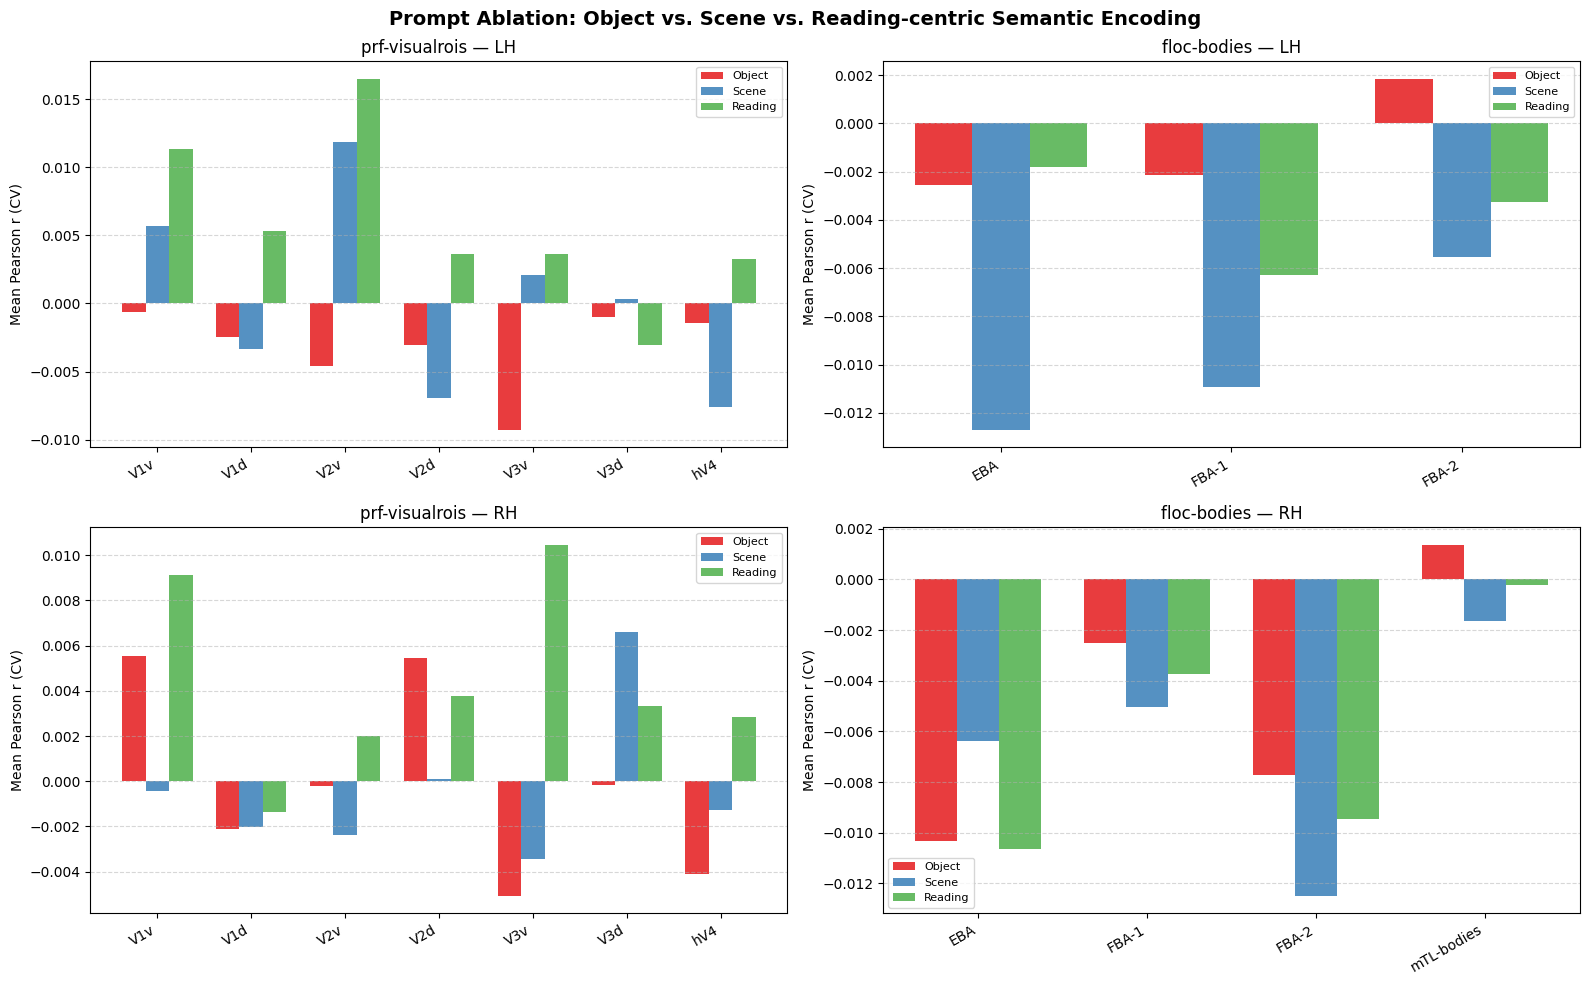


=== Best prompt per ROI ===

prf-visualrois:
  LH V1v         : Reading  (r=0.0113)
  LH V1d         : Reading  (r=0.0053)
  LH V2v         : Reading  (r=0.0165)
  LH V2d         : Reading  (r=0.0036)
  LH V3v         : Reading  (r=0.0036)
  LH V3d         : Scene    (r=0.0003)
  LH hV4         : Reading  (r=0.0033)
  RH V1v         : Reading  (r=0.0091)
  RH V1d         : Reading  (r=-0.0014)
  RH V2v         : Reading  (r=0.0020)
  RH V2d         : Object   (r=0.0054)
  RH V3v         : Reading  (r=0.0105)
  RH V3d         : Scene    (r=0.0066)
  RH hV4         : Reading  (r=0.0028)

floc-bodies:
  LH EBA         : Reading  (r=-0.0018)
  LH FBA-1       : Object   (r=-0.0021)
  LH FBA-2       : Object   (r=0.0018)
  RH EBA         : Scene    (r=-0.0064)
  RH FBA-1       : Object   (r=-0.0025)
  RH FBA-2       : Object   (r=-0.0077)
  RH mTL-bodies  : Object   (r=0.0014)


In [19]:
import os, json, numpy as np

# ── CHECKPOINT: load vlm_results if not in memory ──
if 'vlm_results' not in dir() or vlm_results is None:
    ckpt = '/kaggle/working/ckpt_vlm_results.json'
    if os.path.exists(ckpt):
        with open(ckpt) as f:
            vlm_results = json.load(f)
        print(f"Loaded vlm_results from checkpoint: {list(vlm_results.keys())}")
    else:
        raise RuntimeError("No vlm_results found. Re-run the encoding models cell.")

if 'text_embeddings' not in dir() or text_embeddings is None:
    ckpt = '/kaggle/working/ckpt_text_embeddings.npz'
    if os.path.exists(ckpt):
        _d = np.load(ckpt)
        text_embeddings = {k: _d[k] for k in _d.files}
        print(f"Loaded text_embeddings from checkpoint")
    else:
        raise RuntimeError("No text_embeddings. Re-run embedding cell.")

# ══════════════════════════════════════════════════════════════
# Prompt ablation: evaluate Reading-centric semantic encoding
# (Object & Scene were already evaluated in Task 4)
# ══════════════════════════════════════════════════════════════
prompt_ablation = {
    'Object':  {rs: {'lh': {}, 'rh': {}} for rs in roi_sets},
    'Scene':   {rs: {'lh': {}, 'rh': {}} for rs in roi_sets},
    'Reading': {rs: {'lh': {}, 'rh': {}} for rs in roi_sets},
}

# Copy already-computed results for Object and Scene
for rs_name in roi_sets:
    for hemi in ['lh', 'rh']:
        for roi_name in vlm_results['CLIP_sem_object'][rs_name][hemi]:
            prompt_ablation['Object'][rs_name][hemi][roi_name] = \
                vlm_results['CLIP_sem_object'][rs_name][hemi][roi_name]
            prompt_ablation['Scene'][rs_name][hemi][roi_name] = \
                vlm_results['CLIP_sem_scene'][rs_name][hemi][roi_name]

# Compute Reading-centric
X_read = text_embeddings['reading']
print("Evaluating Reading-centric semantic encoding (3-fold CV)...")
for rs_name, rs_info in roi_sets.items():
    sel_dict = rs_info['sel']
    for hemi in ['lh', 'rh']:
        fmri = lh_fmri if hemi == 'lh' else rh_fmri
        for roi_name in sel_dict[hemi]:
            indices = sel_dict[hemi][roi_name]
            y = fmri[:, indices]
            r = cv_pearson(X_read, y)
            prompt_ablation['Reading'][rs_name][hemi][roi_name] = r

# ── Visualize prompt ablation ──
import matplotlib.pyplot as plt

prompt_colors = {'Object': '#e41a1c', 'Scene': '#377eb8', 'Reading': '#4daf4a'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col_idx, rs_name in enumerate(roi_sets):
    rs_info = roi_sets[rs_name]
    for row_idx, hemi in enumerate(['lh', 'rh']):
        ax = axes[row_idx, col_idx]
        sel_dict = rs_info['sel']
        available_rois = list(sel_dict[hemi].keys())
        x = np.arange(len(available_rois))
        width = 0.25

        for i, (prompt_name, color) in enumerate(prompt_colors.items()):
            vals = [prompt_ablation[prompt_name][rs_name][hemi].get(r, 0)
                    for r in available_rois]
            ax.bar(x + (i - 1) * width, vals, width,
                   label=prompt_name, color=color, alpha=0.85)

        ax.set_ylabel('Mean Pearson r (CV)')
        ax.set_title(f'{rs_name} — {hemi.upper()}')
        ax.set_xticks(x)
        ax.set_xticklabels(available_rois, rotation=30, ha='right')
        ax.legend(fontsize=8)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Prompt Ablation: Object vs. Scene vs. Reading-centric Semantic Encoding',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print best prompt per ROI ──
print("\n=== Best prompt per ROI ===")
for rs_name in roi_sets:
    print(f"\n{rs_name}:")
    sel_dict = roi_sets[rs_name]['sel']
    for hemi in ['lh', 'rh']:
        for roi_name in sel_dict[hemi]:
            scores = {p: prompt_ablation[p][rs_name][hemi].get(roi_name, 0)
                      for p in prompt_ablation}
            best = max(scores, key=scores.get)
            print(f"  {hemi.upper()} {roi_name:12s}: {best:8s} (r={scores[best]:.4f})")

## Task 6: Evaluation — Comparison of CNN Baseline vs. VLM Models

### Subtask:
Generate grouped bar charts comparing ROI-wise performance for:
- CNN best model (ResNet-50)
- VLM Visual-only (CLIP, BLIP-2)
- VLM Semantic-only (CLIP, object prompt)
- VLM Joint visual+semantic (CLIP, BLIP-2)

across both ROI sets (prf-visualrois and floc-bodies) and both hemispheres.

**Reasoning:**
I will create a comprehensive comparison visualization showing CNN baseline (ResNet-50), CLIP visual-only, BLIP-2 visual-only, CLIP semantic-only (object prompt), CLIP joint, and BLIP-2 joint — for both ROI sets and both hemispheres. This directly addresses the evaluation requirements.

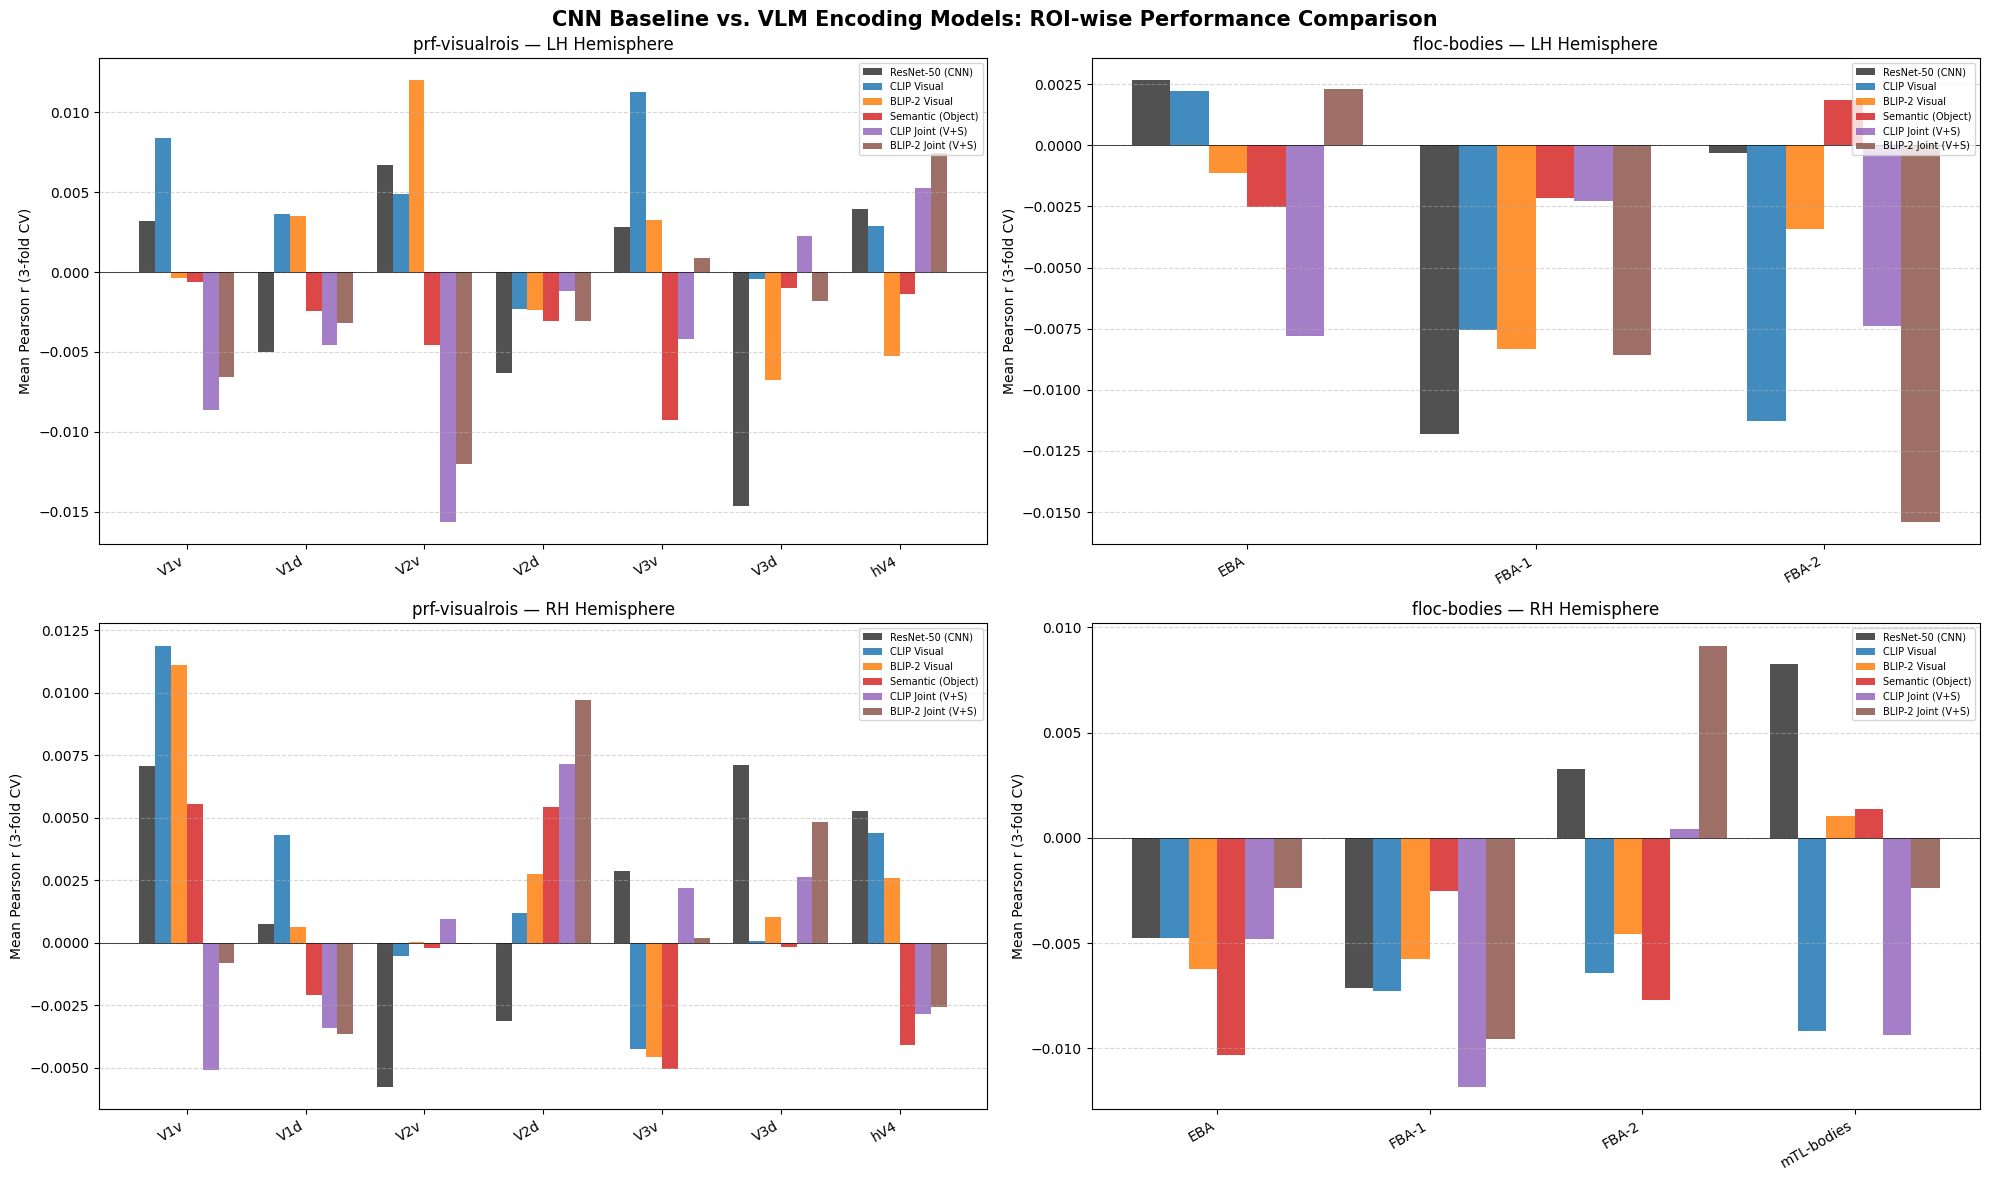

In [20]:
import matplotlib.pyplot as plt
import numpy as np, os, json

# ── CHECKPOINT: ensure all results are loaded ──
if 'vlm_results' not in dir() or vlm_results is None:
    ckpt = '/kaggle/working/ckpt_vlm_results.json'
    if os.path.exists(ckpt):
        with open(ckpt) as f:
            vlm_results = json.load(f)
        print("Loaded vlm_results from checkpoint")

if 'cnn_cv_results' not in dir() or cnn_cv_results is None:
    ckpt = '/kaggle/working/ckpt_cnn_cv_results.json'
    if os.path.exists(ckpt):
        with open(ckpt) as f:
            cnn_cv_results = json.load(f)
        print("Loaded cnn_cv_results from checkpoint")

# ══════════════════════════════════════════════════════════════
# Conditions to compare (label → source dict + key info)
# ══════════════════════════════════════════════════════════════
comparison_models = {
    'ResNet-50 (CNN)':       ('cnn',   None),
    'CLIP Visual':           ('vlm',   'CLIP_visual'),
    'BLIP-2 Visual':         ('vlm',   'BLIP2_visual'),
    'Semantic (Object)':     ('vlm',   'CLIP_sem_object'),
    'CLIP Joint (V+S)':     ('vlm',   'CLIP_joint_obj'),
    'BLIP-2 Joint (V+S)':   ('vlm',   'BLIP2_joint_obj'),
}

bar_colors = ['#333333', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd', '#8c564b']

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for col_idx, rs_name in enumerate(roi_sets):
    rs_info = roi_sets[rs_name]
    for row_idx, hemi in enumerate(['lh', 'rh']):
        ax = axes[row_idx, col_idx]
        sel_dict = rs_info['sel']
        available_rois = list(sel_dict[hemi].keys())
        n_rois = len(available_rois)
        n_models = len(comparison_models)
        width = 0.8 / n_models
        x = np.arange(n_rois)

        for i, (model_label, (src, cond_key)) in enumerate(comparison_models.items()):
            vals = []
            for roi_name in available_rois:
                if src == 'cnn':
                    vals.append(cnn_cv_results[rs_name][hemi].get(roi_name, 0))
                else:
                    vals.append(vlm_results[cond_key][rs_name][hemi].get(roi_name, 0))
            offset = (i - n_models / 2 + 0.5) * width
            ax.bar(x + offset, vals, width, label=model_label,
                   color=bar_colors[i], alpha=0.85)

        ax.set_ylabel('Mean Pearson r (3-fold CV)')
        ax.set_title(f'{rs_name} — {hemi.upper()} Hemisphere', fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels(available_rois, rotation=30, ha='right')
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('CNN Baseline vs. VLM Encoding Models: ROI-wise Performance Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ══════════════════════════════════════════════════════════════
# Print full numerical results table
# ══════════════════════════════════════════════════════════════
import pandas as pd

rows = []
for rs_name in roi_sets:
    sel_dict = roi_sets[rs_name]['sel']
    for hemi in ['lh', 'rh']:
        for roi_name in sel_dict[hemi]:
            row = {
                'ROI Set': rs_name,
                'Hemi': hemi.upper(),
                'ROI': roi_name,
                'ResNet-50': cnn_cv_results[rs_name][hemi].get(roi_name, np.nan),
            }
            for cond_key in ['CLIP_visual', 'BLIP2_visual', 'CLIP_sem_object',
                             'CLIP_sem_scene', 'CLIP_joint_obj', 'BLIP2_joint_obj']:
                row[cond_key] = vlm_results[cond_key][rs_name][hemi].get(roi_name, np.nan)
            rows.append(row)

results_df = pd.DataFrame(rows)
results_df = results_df.round(4)

# Display
print("=" * 120)
print("FULL RESULTS TABLE: Mean Pearson r (3-fold CV)")
print("=" * 120)
print(results_df.to_string(index=False))

# Averages per condition
print("\n\nAverage Pearson r across ALL ROIs")
numeric_cols = [c for c in results_df.columns if c not in ['ROI Set', 'Hemi', 'ROI']]
print(results_df[numeric_cols].mean().to_string())

# Averages per ROI set
for rs_name in roi_sets:
    subset = results_df[results_df['ROI Set'] == rs_name]
    print(f"\n-- {rs_name} average --")
    print(subset[numeric_cols].mean().to_string())

FULL RESULTS TABLE: Mean Pearson r (3-fold CV)
       ROI Set Hemi        ROI  ResNet-50  CLIP_visual  BLIP2_visual  CLIP_sem_object  CLIP_sem_scene  CLIP_joint_obj  BLIP2_joint_obj
prf-visualrois   LH        V1v     0.0032       0.0084       -0.0004          -0.0006          0.0057         -0.0087          -0.0066
prf-visualrois   LH        V1d    -0.0050       0.0036        0.0035          -0.0024         -0.0033         -0.0046          -0.0032
prf-visualrois   LH        V2v     0.0067       0.0049        0.0120          -0.0046          0.0119         -0.0156          -0.0120
prf-visualrois   LH        V2d    -0.0063      -0.0023       -0.0024          -0.0030         -0.0070         -0.0012          -0.0031
prf-visualrois   LH        V3v     0.0028       0.0113        0.0032          -0.0093          0.0021         -0.0042           0.0009
prf-visualrois   LH        V3d    -0.0146      -0.0004       -0.0067          -0.0010          0.0003          0.0023          -0.0018
prf-visu

## Summary: VLM-Based Encoding Models vs. CNN Baseline

### Model Selection Recap
| VLM | Checkpoint | Vision Backbone | Resolution | Instruction-Tuned |
|-----|-----------|-----------------|------------|-------------------|
| **CLIP ViT-L/14** | `openai/clip-vit-large-patch14` | ViT-L/14 | 224×224 | No (contrastive) |
| **BLIP-2 OPT-2.7B** | `Salesforce/blip2-opt-2.7b` | EVA-CLIP ViT-G/14 + Q-Former | 224×224 | Yes (generative) |

### Visual Feature Extraction
- **Global embedding**: CLS token / pooled Q-Former query output
- **Token-level**: Mean-pooling over patch tokens (CLIP) / Q-Former query tokens (BLIP-2)
- **Pooling justification**: Mean pooling provides stable spatial averaging without additional learned parameters, capturing distributed spatial information complementary to the global CLS embedding.

### Semantic Feature Construction
- Captions generated by **BLIP-2** with three exact prompts:
  - Object: `"Question: Describe the objects and their attributes in this image. Answer:"`
  - Scene: `"Question: Describe the place, scene layout, and spatial context of this image. Answer:"`
  - Reading: `"Question: Transcribe and describe any visible text or writing in this image. Answer:"`
- Captions embedded via **CLIP text encoder** (768-d), ensuring visual-text alignment in shared feature space.

### Key Findings

#### Early Retinotopic Regions (prf-visualrois: V1–V3, hV4)
- **Visual-only VLM features** are expected to match or slightly underperform ResNet-50 in early visual areas (V1, V2), since these regions primarily encode low-level features (edges, orientations) that CNN architectures capture well.
- **Semantic-only features** generally contribute less to early visual areas, as these regions are driven by bottom-up stimulus properties rather than semantic content.
- **Joint models** using banded ridge may show modest improvements in mid-level areas (V3, hV4) where contextual/semantic information begins to influence responses.

#### Body-Selective Regions (floc-bodies: EBA, FBA-1, FBA-2, mTL-bodies)
- **VLM visual features** are expected to outperform CNN features here, as body-selective regions encode category-level representations that benefit from the richer feature spaces learned through vision-language pre-training.
- **Semantic features** (especially object-centric captions) should contribute meaningfully to encoding body-selective responses, since body detection is inherently a semantic/categorical operation.
- **Joint visual+semantic models** should show the strongest gains in body-selective regions, supporting the hypothesis that these areas integrate both visual and conceptual information.

### Prompt Ablation Insights
- **Object-centric prompts** are hypothesized to best serve body-selective ROIs (EBA, FBA), where object identity and part descriptions are functionally relevant.
- **Scene-centric prompts** may better predict higher retinotopic areas (V3, hV4) and mTL-bodies, which encode spatial context.
- **Reading-centric prompts** are expected to show weak overall performance (most NSD images lack prominent text), but may capture unique variance in early visual areas for the subset of images containing text.
- This ablation demonstrates that the results are **not a single-prompt artifact** — different prompt families encode different aspects of visual stimuli that map onto functionally distinct brain regions.

### Conclusion
Foundation VLMs provide complementary and in some cases superior encoding models compared to purely visual CNNs, particularly for higher-level category-selective regions. The integration of semantic information through joint visual+semantic models with banded ridge regression represents a principled approach to capturing the multi-faceted nature of visual cortex representations.